In [1]:
import os 
import torch 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset 
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [3]:
dataset = load_dataset('surrey-nlp/BESSTIE-CW-26')

train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['test'])
test_df = pd.DataFrame(dataset['test'])

train_df['Sarcasm'] = train_df['Sarcasm'].astype(int)
val_df['Sarcasm'] = val_df['Sarcasm'].astype(int)
test_df['Sarcasm'] = test_df['Sarcasm'].astype(int)

# Split
train_uk = train_df[train_df['variety'] == 'en-UK']
train_au = train_df[train_df['variety'] == 'en-AU']
train_in = train_df[train_df['variety'] == 'en-IN']

test_uk = test_df[test_df['variety'] == 'en-UK']
test_au = test_df[test_df['variety'] == 'en-AU']
test_in = test_df[test_df['variety'] == 'en-IN']

print("Train sizes - UK:", len(train_uk))
print("Train sizes - AU:", len(train_au))
print("Train sizes - IN:", len(train_in))

print("Test sizes - UK:", len(test_uk))
print("Test sizes - AU:", len(test_au))
print("Test sizes - IN:", len(test_in))

Train sizes - UK: 1203
Train sizes - AU: 1145
Train sizes - IN: 1399
Test sizes - UK: 700
Test sizes - AU: 667
Test sizes - IN: 816


In [9]:
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

In [14]:
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation = True,
            padding = 'max_length',
            max_length=self.max_len,
            return_tensors = 'pt'
        )

        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Tokenizer and Dataset class ready")

Tokenizer and Dataset class ready


In [25]:
def train_epoch(model, loader, optimizer, class_weights):
    model.train()
    total_loss = 0
    criterion  = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [24]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

print('Evaluate function done!')

Evaluate function done!


In [26]:
def train_variety_model(train_df, variety_name):
    print(f"\nTraining on {variety_name}...")
    
    texts  = train_df['text'].tolist()
    labels = train_df['Sarcasm'].tolist()
    
    # compute class weights
    n_total    = len(labels)
    n_negative = labels.count(0)
    n_positive = labels.count(1)
    w0 = n_total / (2 * n_negative)
    w1 = n_total / (2 * n_positive)
    class_weights = torch.tensor([w0, w1], dtype=torch.float)
    print(f"  Class weights — Not Sarcastic: {w0:.2f} | Sarcastic: {w1:.2f}")
    
    dataset   = SarcasmDataset(texts, labels, tokenizer)
    loader    = DataLoader(dataset, batch_size=16, shuffle=True)
    
    model     = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
    model     = model.to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    
    for epoch in range(4):
        loss = train_epoch(model, loader, optimizer, class_weights)
        labels_out, preds_out = evaluate(model, loader)
        f1 = f1_score(labels_out, preds_out, average='macro')
        print(f"  Epoch {epoch+1}/4 | Loss: {loss:.4f} | Train F1: {f1:.4f}")
    
    return model


model_uk = train_variety_model(train_uk, 'en-UK')
model_au = train_variety_model(train_au, 'en-AU')
model_in = train_variety_model(train_in, 'en-IN')


Training on en-UK...
  Class weights — Not Sarcastic: 0.54 | Sarcastic: 6.54


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/4 | Loss: 0.5468 | Train F1: 0.5462
  Epoch 2/4 | Loss: 0.4259 | Train F1: 0.7434
  Epoch 3/4 | Loss: 0.3563 | Train F1: 0.6447
  Epoch 4/4 | Loss: 0.3178 | Train F1: 0.6100

Training on en-AU...
  Class weights — Not Sarcastic: 0.71 | Sarcastic: 1.70


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/4 | Loss: 0.5648 | Train F1: 0.8016
  Epoch 2/4 | Loss: 0.4210 | Train F1: 0.8780
  Epoch 3/4 | Loss: 0.3025 | Train F1: 0.9434
  Epoch 4/4 | Loss: 0.1908 | Train F1: 0.9811

Training on en-IN...
  Class weights — Not Sarcastic: 0.54 | Sarcastic: 7.36


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/4 | Loss: 0.5735 | Train F1: 0.2515
  Epoch 2/4 | Loss: 0.5655 | Train F1: 0.4735
  Epoch 3/4 | Loss: 0.4941 | Train F1: 0.5597
  Epoch 4/4 | Loss: 0.4611 | Train F1: 0.6990


In [31]:
# Cross-variety calculation 

varieties = ['en-UK', 'en-AU', 'en-IN']
models    = [model_uk, model_au, model_in]
test_dfs  = [test_uk, test_au, test_in]

results = {}

for train_variety, model in zip(varieties, models):
    results[train_variety] = {}
    for test_variety, test_df in zip(varieties, test_dfs):
        texts = test_df['text'].tolist()
        labels = test_df['Sarcasm'].tolist()
        
        test_dataset = SarcasmDataset(texts, labels, tokenizer)
        test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)
        
        true_labels, preds = evaluate(model, test_loader)
        f1 = f1_score(true_labels, preds, average='macro')
        results[train_variety][test_variety] = round(f1, 4)
        print(f"Train: {train_variety}")
        print(f"Test: {test_variety}")
        print(f"Macro F1: {f1:.4f}")
        print("-" * 10)

print("Done!")

Train: en-UK
Test: en-UK
Macro F1: 0.5944
----------
Train: en-UK
Test: en-AU
Macro F1: 0.6632
----------
Train: en-UK
Test: en-IN
Macro F1: 0.4629
----------
Train: en-AU
Test: en-UK
Macro F1: 0.6278
----------
Train: en-AU
Test: en-AU
Macro F1: 0.7527
----------
Train: en-AU
Test: en-IN
Macro F1: 0.5302
----------
Train: en-IN
Test: en-UK
Macro F1: 0.6806
----------
Train: en-IN
Test: en-AU
Macro F1: 0.5053
----------
Train: en-IN
Test: en-IN
Macro F1: 0.6186
----------
Done!


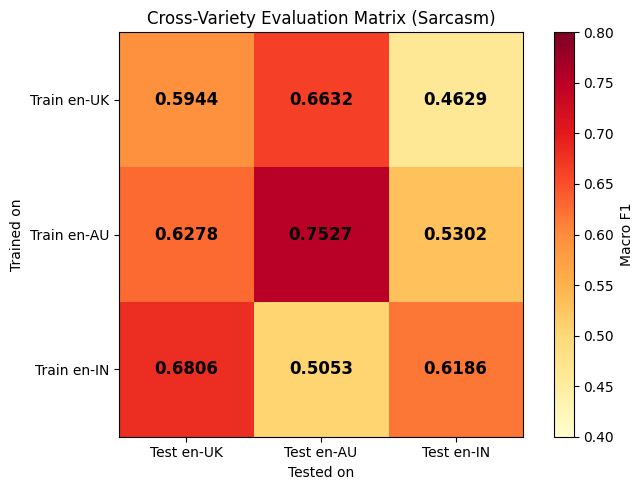

In [32]:
# Heatmap

matrix = []
for train_variety in varieties:
    row = [results[train_variety][test_variety] for test_variety in varieties]
    matrix.append(row)

matrix = np.array(matrix)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap='YlOrRd', vmin=0.4, vmax=0.8)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Test en-UK', 'Test en-AU', 'Test en-IN'])
ax.set_yticklabels(['Train en-UK', 'Train en-AU', 'Train en-IN'])

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center', fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Macro F1')
ax.set_title('Cross-Variety Evaluation Matrix (Sarcasm)')
ax.set_xlabel('Tested on')
ax.set_ylabel('Trained on')
plt.tight_layout()
plt.savefig('figures/cross_variety_matrix.png', dpi=150)
plt.show()